# Control predictivo ponderado

In [12]:

import numpy as np
import matplotlib.pyplot as plt
import scipy as sc
import control as ctrl
from scipy.signal import lfilter


## Calculo del predictor

In [2]:
def calcularPolinomiosPredictivo(A,Bp,d):
    # Calculo de polinomios del predictor
    F = lfilter([1], A, np.r_[1, np.zeros(d-1)])
    Gp = np.r_[1,np.zeros(len(A)+d-2)] - np.polymul(A,F) 
    G = Gp[d:]
    FBp = np.polymul(F,Bp)

    print("F =", F)
    print("G =", G)  
    print(f'Prueba ec Diofantina: AF+q^(-d)G ={np.polymul(A,F)+np.r_[np.zeros(d),G]}')
    return F,G,FBp

## Simulación del control predictivo ponderado

F = [1.   1.74]
G = [ 2.2576 -1.3398]
Prueba ec Diofantina: AF+q^(-d)G =[1. 0. 0. 0.]
F = [1.   1.74]
G = [ 2.2576 -1.3398]
Prueba ec Diofantina: AF+q^(-d)G =[1. 0. 0. 0.]
F = [1.   1.74]
G = [ 2.2576 -1.3398]
Prueba ec Diofantina: AF+q^(-d)G =[1. 0. 0. 0.]
F = [1.   1.74]
G = [ 2.2576 -1.3398]
Prueba ec Diofantina: AF+q^(-d)G =[1. 0. 0. 0.]


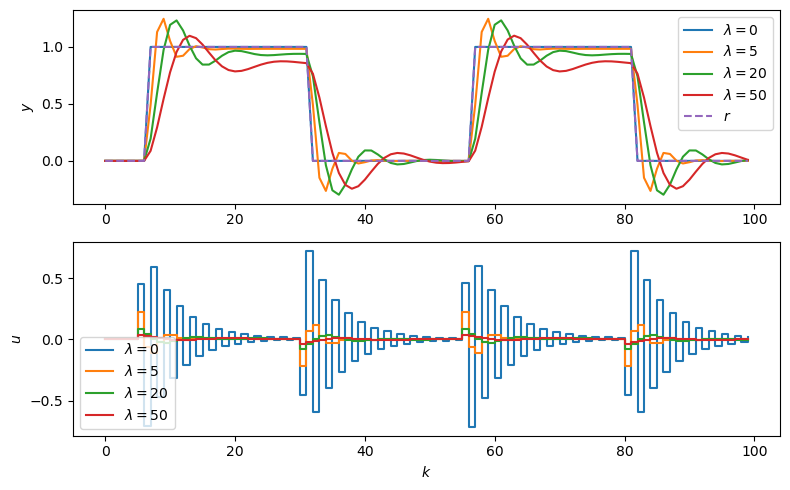

In [3]:
def simularControlPredictivoPonderado(A,Bp,d,r,v=None,lambda_=0,plot=True,deltaA=None,deltaB=None):
    F,G,FBp = calcularPolinomiosPredictivo(A,Bp,d)

    A_ = A; Bp_ = Bp
    if deltaA is not None:
        A_ = A.copy() * (1+deltaA)
    if deltaB is not None:
        Bp_ = Bp.copy() * (1+deltaB)
    

    # señales
    N = len(r)
    k = np.arange(N)
    u = np.zeros(N)
    uv = np.zeros(N)
    y = np.zeros(N)

    for kk in range(d+len(Bp),N):

        # ===== Control predictivo =====
        # y_hat_d = G*y + FB' * u  (pero evaluado en k)
        #Gy = np.sum(G[1:] * y[kk-np.arange(1,len(Ap))])
        #FBpu = np.sum(FBp[1:] * u[kk-np.arange(1,len(FBp))])

        Gy     = np.dot(G, y[kk:kk-len(G):-1]) 
        FBpu   = np.dot(FBp[1:], u[kk-1:kk-len(FBp):-1]) 
        # ecuación óptima: FB' u_k = r_{k+d} - Gy
        u[kk] = ((r[kk+d] if kk+d<N else r[-1]) - Gy - FBpu)/ (Bp[0]+lambda_/Bp[0])
        uv[kk] = u[kk] + (v[kk-d] if v is not None else 0)

        # ===== Simulación de la Planta =====
        # parte autoregresiva de la salida
        y_AR = np.dot(-A_[1:],y[kk:kk-len(A_)+1:-1])    
        # parte que depende de la entrada retrasada
        y_X = np.dot(Bp_, uv[kk-d+1:kk-d+1-len(Bp_):-1])
        # salida total
        if kk<N-1:
            y[kk+1] = y_AR + y_X


    # ===========================================
    # Graficos
    # ===========================================
    if plot:
        plt.figure(figsize=(8,5))
        plt.subplot(211)
        plt.plot(k, r, '--', label='$r$')#,where='post')
        plt.plot(k, y, label='$y$')
        plt.legend()
        plt.subplot(212)
        plt.step(k, u, label='$u$',where='post')
        plt.legend()
        plt.xlabel("k")
        plt.tight_layout()
        plt.show()

    return y,u


A = np.r_[1, -1.74, .77]
Bp = 2 * np.r_[1.1, .9]
d = 2

k = np.arange(100)
r = 0.5 * (sc.signal.square(2*np.pi * k / 50 - np.pi/4) + 1)

plt.figure(figsize=(8,5))
for lambda_ in [0,5,20,50]:
    y,u = simularControlPredictivoPonderado(A,Bp,d,r,lambda_=lambda_,plot=False)
    plt.subplot(211)
    plt.plot(k, y, label=f'$\lambda=${lambda_}')
    plt.subplot(212)
    plt.step(k, u, label=f'$\lambda=${lambda_}',where='post')
    
plt.legend()
plt.xlabel('$k$')
plt.ylabel('$u$')
plt.subplot(211)
plt.plot(k, r, '--', label='$r$')
plt.ylabel('$y$')
plt.legend()
plt.tight_layout()
plt.show()


## Efecto de las incertidumbres en el control predictivo ponderado

F = [1.   1.74]
G = [ 2.2576 -1.3398]
Prueba ec Diofantina: AF+q^(-d)G =[1. 0. 0. 0.]
F = [1.   1.74]
G = [ 2.2576 -1.3398]
Prueba ec Diofantina: AF+q^(-d)G =[1. 0. 0. 0.]
F = [1.   1.74]
G = [ 2.2576 -1.3398]
Prueba ec Diofantina: AF+q^(-d)G =[1. 0. 0. 0.]


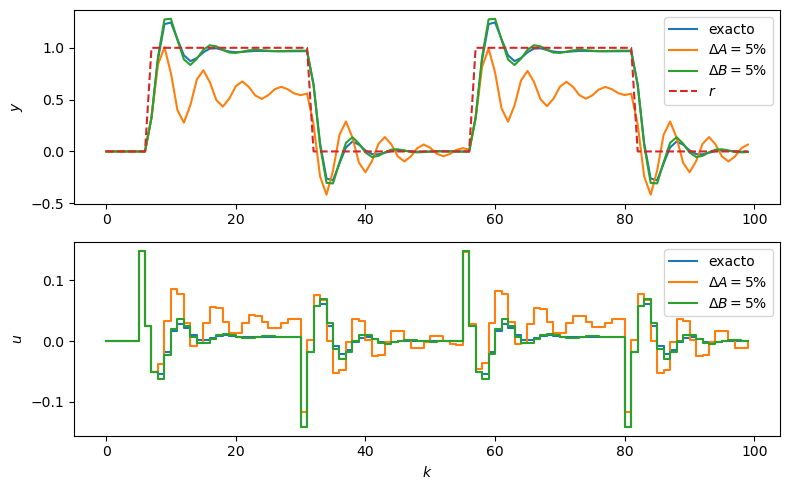

In [4]:
A = np.r_[1, -1.74, .77]
Bp = 2 * np.r_[1.1, .9]
d = 2

y,u = simularControlPredictivoPonderado(A,Bp,d,r,lambda_=10,plot=False)

dA = 5
deltaA = np.r_[0, -1.74*dA/100.0, .77*dA/100.0]
ya,ua = simularControlPredictivoPonderado(A,Bp,d,r,lambda_=10,plot=False,deltaA=deltaA)

dB = 5
deltaB = 2 * np.r_[0, .9*dB/100.0]
yb,ub = simularControlPredictivoPonderado(A,Bp,d,r,lambda_=10,plot=False,deltaB=deltaB)

plt.figure(figsize=(8,5))
plt.subplot(211)
plt.plot(k, y, label=f'exacto')
plt.plot(k, ya, label=f'$\Delta A ={dA}\%$')
plt.plot(k, yb, label=f'$\Delta B ={dB}\%$')
plt.plot(k, r, '--', label='$r$')
plt.ylabel('$y$')
plt.legend()

plt.subplot(212)
plt.step(k, u, label=f'exacto',where='post')
plt.step(k, ua, label=f'$\Delta A ={dA}\%$',where='post')
plt.step(k, ub, label=f'$\Delta B ={dB}\%$',where='post')
plt.legend()
plt.xlabel('$k$')
plt.ylabel('$u$')
plt.tight_layout()
plt.show()


## Control predictivo ponderado con modelo CARIMA

F = [1.         1.74       2.2576     2.588424   2.76550576]
G = [ 2.81889354 -2.12943944]
Prueba ec Diofantina: AF+q^(-d)G =[1. 0. 0. 0. 0. 0. 0.]
F = [ 1.          2.74        4.9976      7.586024   10.35152976]
G = [ 13.1704233  -20.14110122   7.97067792]
Prueba ec Diofantina: AF+q^(-d)G =[1. 0. 0. 0. 0. 0. 0. 0.]
[-1.60042635+1.01242205j -1.60042635-1.01242205j  0.23042635+1.68322975j
  0.23042635-1.68322975j  0.9       +0.j        ]
[0.77794297 0.77794297]


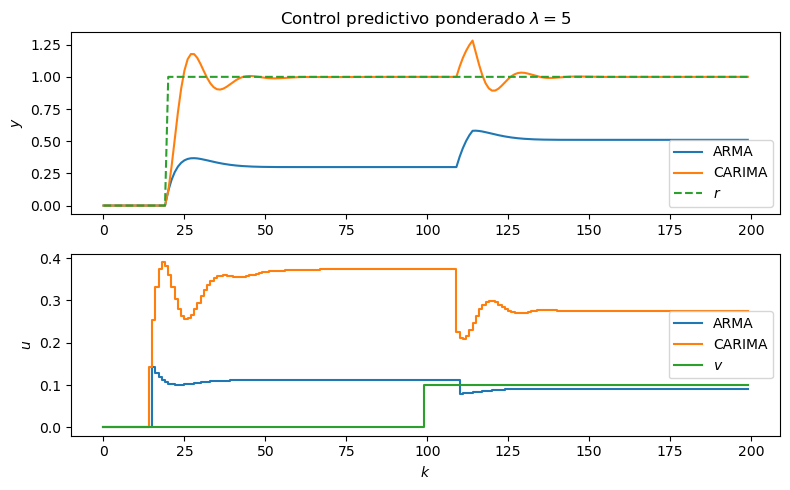

In [5]:
def simularControlPredictivoPonderadoCarima(A,Bp,d,r,v=None,lambda_=0,plot=True,deltaA=None,deltaB=None):
    Ap = np.polymul(A,np.r_[1,-1])
    F,G,FBp = calcularPolinomiosPredictivo(Ap,Bp,d)
    print(np.roots(FBp))
    print(np.abs(np.roots(G)))

    A_ = A; Bp_ = Bp
    if deltaA is not None:
        A_ = A.copy() * (1+deltaA)
    if deltaB is not None:
        Bp_ = Bp.copy() * (1+deltaB)
    

    # señales
    N = len(r)
    k = np.arange(N)
    u = np.zeros(N)
    uv = np.zeros(N)
    du = np.zeros(N)
    y = np.zeros(N)

    for kk in range(d+len(Bp),N):

        # ===== Control predictivo =====
        # y_hat_d = G*y + FB' * u  (pero evaluado en k)
        #Gy = np.sum(G[1:] * y[kk-np.arange(1,len(Ap))])
        #FBpu = np.sum(FBp[1:] * u[kk-np.arange(1,len(FBp))])

        Gy     = np.dot(G, y[kk:kk-len(G):-1]) 
        FBpDu   = np.dot(FBp[1:], du[kk-1:kk-len(FBp):-1]) 
        # ecuación óptima: FB' u_k = r_{k+d} - Gy
        du[kk] = ((r[kk+d] if kk+d<N else r[-1]) - Gy - FBpDu)/ (Bp[0]+lambda_/Bp[0]) 
        u[kk] = u[kk-1] + du[kk]
        uv[kk] = u[kk] + (v[kk-d] if v is not None else 0)

        # ===== Simulación de la Planta =====
        # parte autoregresiva de la salida
        y_AR = np.dot(-A_[1:],y[kk:kk-len(A_)+1:-1])    
        # parte que depende de la entrada retrasada
        y_X = np.dot(Bp_, uv[kk-d+1:kk-d+1-len(Bp_):-1])
        # salida total
        if kk<N-1:
            y[kk+1] = y_AR + y_X


    # ===========================================
    # Graficos
    # ===========================================
    if plot:
        plt.figure(figsize=(8,5))
        plt.subplot(211)
        plt.step(k, r, '--', label='$r$',where='post')
        plt.plot(k, y, label='$y$')
        plt.legend()
        plt.subplot(212)
        plt.step(k, u, label='$u$',where='post')
        if v is not None:
            plt.step(k, v, label='$v$',where='post')
        plt.legend()
        plt.xlabel("k")
        plt.tight_layout()
        plt.show()

    return y,u

A = np.r_[1, -1.74, .77]
Bp = 0.8*np.r_[1, -.9]
d = 5

N = 200
k = np.arange(N)
r = np.zeros(N)
r[20:] = 1
v = np.zeros_like(r)
v[100:] = 0.1

lambda_ = 5

y,u = simularControlPredictivoPonderado(A,Bp,d,r,v=v,lambda_=lambda_,plot=False)
yc,uc = simularControlPredictivoPonderadoCarima(A,Bp,d,r,v=v,lambda_=lambda_,plot=False)

plt.figure(figsize=(8,5))
plt.subplot(211)
plt.plot(k, y, label=f'ARMA')
plt.plot(k, yc, label='CARIMA')
plt.plot(k, r, '--', label='$r$')
plt.ylabel('$y$')
plt.legend()
plt.title(f'Control predictivo ponderado $\lambda=${lambda_}')

plt.subplot(212)
plt.step(k, u, label=f'ARMA',where='post')
plt.step(k, uc, label=f'CARIMA')
plt.step(k, v, label=f'$v$')
plt.legend()
plt.xlabel('$k$')
plt.ylabel('$u$')
plt.tight_layout()
plt.show()




## Evolución de los polos
Se compara el ponderado sobre los modelos ARMA y CARIMA

Raices iniciales (lambda=0): [0.9+0.j 0. +0.j]


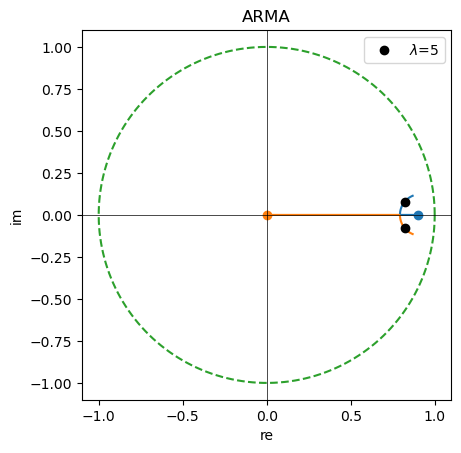

Raices iniciales (lambda=0): [0.9+0.j 0. +0.j 0. +0.j]


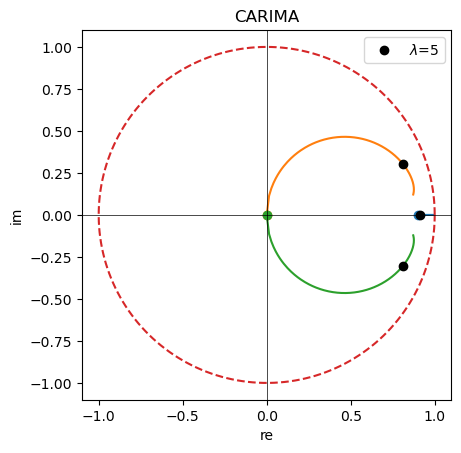

In [6]:
def rlocus_lambda(A,Bp,lambda_extr=(0,50),N_lambdas=200,lambda_show=None,title="Evolución de raíces según $\lambda$"):
    grado = len(A)   # número de coeficientes del polinomio
    lambdas_ = np.linspace(lambda_extr[0],lambda_extr[1],N_lambdas)  # cantidad de iteraciones

    raices = np.zeros((len(lambdas_),len(A)-1), dtype=complex)

    for i, lambda_ in enumerate(lambdas_):
        den = np.r_[Bp*Bp[0], np.zeros(len(A)-len(Bp))] + A*lambda_
        raices[i,:] = np.roots(den)    

    print(f'Raices iniciales (lambda=0): {raices[0,:]}')
    for n in range(grado-1):
        line, = plt.plot(np.real(raices[:,n]),np.imag(raices[:,n]))
        color = line.get_color()
        plt.plot(np.real(raices[0,n]),np.imag(raices[0,n]),'o',color=color)        
    if lambda_show is not None:
        n = np.argmin(np.abs(lambdas_-lambda_show))
        plt.plot(np.real(raices[n,:]),np.imag(raices[n,:]),'ko',label=f'$\lambda$={lambda_show}')
        plt.legend()

    theta = np.linspace(0, 2*np.pi, 400)
    x = np.cos(theta)
    y = np.sin(theta)
    plt.plot(x, y, '--')   # círculo unitario punteado

    # --- Decoración ---
    plt.axhline(0, color='black', linewidth=0.5)
    plt.axvline(0, color='black', linewidth=0.5)
    plt.gca().set_aspect('equal', 'box')
    plt.title(title)
    plt.xlabel("re")
    plt.ylabel("im")
    #plt.grid(True)

    plt.show()

rlocus_lambda(A,Bp,lambda_extr=(0,200),N_lambdas=20000,lambda_show=lambda_,title='ARMA')
rlocus_lambda(np.polymul(A,[1,-1]),Bp,lambda_extr=(0,200),N_lambdas=20000,lambda_show=lambda_,title='CARIMA')

# Ponderación por polinomios

Se plantea una señal filtrada:

$$u_f = \frac{R}{P} u$$

De esta forma se puede ajustar mejor la ponderación. Por ejemplo haciendo que se penalicen más los cambios en la actuación (altas frecuencias) que los valores medios obtenidos en ella.

Además se puede seguir escalones con error de estado estacionario nulo haciendo que 

$$ R=(1-q^{-1})R'$$

Sin embargo esto no significa que tenga rechazo a perturbaciones escalón

La acción de control implementada se resume en:
$$ \epsilon_k=r_{k+d}-G y_k\\
[FB'Pb_0+\lambda R] u_k = Pb_0 \epsilon_k
$$

Despejando $u_k$ y atendiendo que la expresión $(X-1)$ indica que al polinomio X mónico se le substrae el elemento independiente $q^0$, la ley de control resulta:

$$u_k = \frac{1}{b_0^2+\lambda}\left[Pb_0 \epsilon_k + (b_0^2+\lambda - FB'Pb_0+\lambda R) u_k\right] $$




Polinomio P=[ 1.     -1.3981  0.4976]
Polinomio R=[ 1.     -0.9473  0.1205]
F = [1.   1.74]
G = [ 2.2576 -1.3398]
Prueba ec Diofantina: AF+q^(-d)G =[1. 0. 0. 0.]
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.

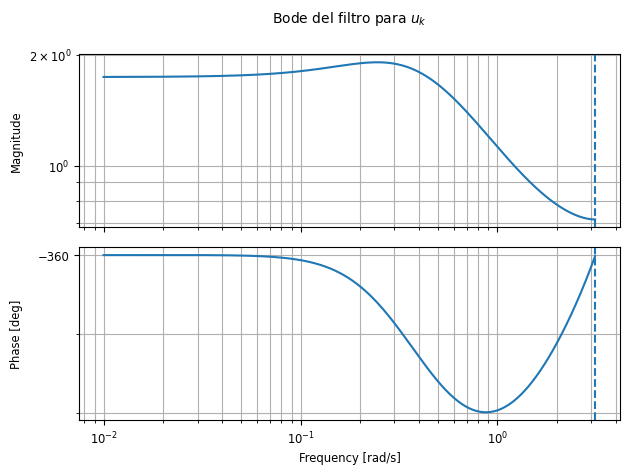

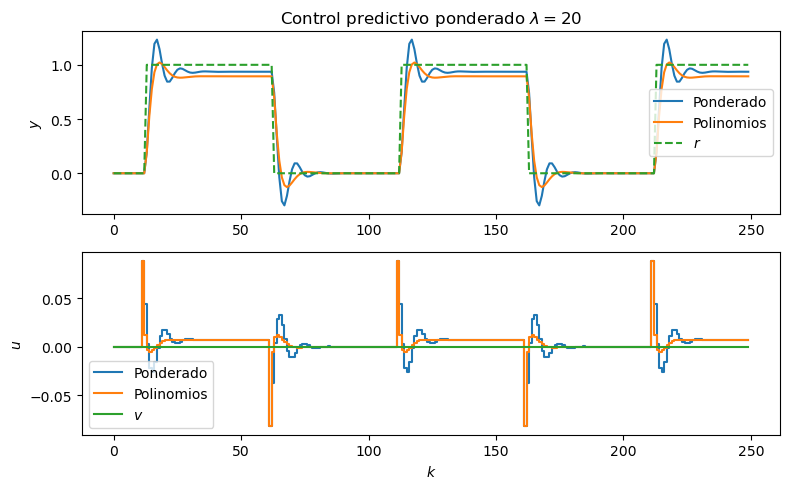

In [ ]:
def simularControlPredictivoPonderadoPolinomios(A,Bp,d,r,R=np.r_[1],P=np.r_[1],v=None,lambda_=0,plot=True,deltaA=None,deltaB=None):
    F,G,FBp = calcularPolinomiosPredictivo(A,Bp,d)

    A_ = A; Bp_ = Bp
    if deltaA is not None:
        A_ = A.copy() * (1+deltaA)
    if deltaB is not None:
        Bp_ = Bp.copy() * (1+deltaB)
    

    # señales
    N = len(r)
    k = np.arange(N)
    u = np.zeros(N)
    epsilon = np.zeros(N)
    uv = np.zeros(N)
    y = np.zeros(N)

    for kk in range(d+len(Bp)+len(P),N):
        # ===== Control predictivo =====
        # y_hat_d = G*y + FB' * u  (pero evaluado en k)        
        Gy     = np.dot(G, y[kk:kk-len(G):-1]) 
        epsilon[kk] = (r[kk+d] if kk+d<N else r[-1]) - Gy 
        FBpPb0 = np.polymul(FBp,P)*Bp[0]
        FBpPb0_lR = FBpPb0+np.r_[lambda_*R,np.zeros(len(FBpPb0)-len(R))]
        FBpPb0_lRu   = np.dot(FBpPb0_lR[1:], u[kk-1:kk-len(FBpPb0_lR):-1])
        
        # ecuación óptima: (FB'Pb0+lambda R) * u_k = Pb0*(epsilon)
        Pb0epsilon   = np.dot(Bp[0]*P, epsilon[kk:kk-len(P):-1])
        u[kk] = (Pb0epsilon - FBpPb0_lRu)/FBpPb0_lR[0]
        uv[kk] = u[kk] + (v[kk-d] if v is not None else 0)

        # ===== Simulación de la Planta =====
        # parte autoregresiva de la salida
        y_AR = np.dot(-A_[1:],y[kk:kk-len(A_)+1:-1])    
        # parte que depende de la entrada retrasada
        y_X = np.dot(Bp_, uv[kk-d+1:kk-d+1-len(Bp_):-1])
        # salida total
        if kk<N-1:
            y[kk+1] = y_AR + y_X


    # ===========================================
    # Graficos
    # ===========================================
    if plot:
        plt.figure(figsize=(8,5))
        plt.subplot(211)
        plt.plot(k, r, '--', label='$r$')#,where='post')
        plt.plot(k, y, label='$y$')
        plt.legend()
        plt.subplot(212)
        plt.step(k, u, label='$u$',where='post')
        plt.legend()
        plt.xlabel("k")
        plt.tight_layout()
        plt.show()

    return y,u

A = np.r_[1, -1.74, .77]
Bp = 2 * np.r_[1.1, .9]
d = 2

k = np.arange(250)
r = 0.5 * (sc.signal.square(2*np.pi * k / 100 - np.pi/4) + 1)
v = np.zeros_like(r)
v[125:] = 0*0.015

lambda_ = 20
P = np.r_[1, -1.3981, 0.4976]
R = np.r_[1, -0.9473, 0.1205]
#R = np.poly([0.15,1])
#P = np.poly([0.95,0.95])
#R = np.poly([0,1])
print(f'Polinomio P={P}')
print(f'Polinomio R={R}')
ctrl.bode_plot(ctrl.TransferFunction(R,P,dt=1),title='Bode del filtro para $u_k$')

y,u = simularControlPredictivoPonderadoPolinomios(A,Bp,d,r,v=v,lambda_=lambda_,plot=False)
yp,up = simularControlPredictivoPonderadoPolinomios(A,Bp,d,r,v=v,R=R,P=P,lambda_=lambda_,plot=False)


plt.figure(figsize=(8,5))
plt.subplot(211)
plt.plot(k, y, label=f'Ponderado')
plt.plot(k, yp, label='Polinomios')
plt.plot(k, r, '--', label='$r$')
plt.ylabel('$y$')
plt.legend()
plt.title(f'Control predictivo ponderado $\lambda=${lambda_}')

plt.subplot(212)
plt.step(k, u, label=f'Ponderado',where='post')
plt.step(k, up, label=f'Polinomios',where='post')
plt.step(k, v, label=f'$v$')
plt.legend()
plt.xlabel('$k$')
plt.ylabel('$u$')
plt.tight_layout()
plt.show()


